In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import os
import numpy as np
from scipy.stats import ttest_ind, ttest_ind_from_stats, mannwhitneyu, wilcoxon

FONT_SIZE_TITLE=14
FONT_SIZE=12

In [2]:
conn = duckdb.connect("../results/results.duckdb")

In [3]:
conn.query("SELECT experiments.lakehouse, COUNT(events.*) AS events_consumed " \
"FROM experiments " \
"JOIN events ON events.experiment_id = experiments.id " \
"GROUP BY experiments.id, experiments.client, experiments.lakehouse " \
"ORDER BY experiments.id;")

┌─────────────────────┬─────────────────┐
│      lakehouse      │ events_consumed │
│       varchar       │      int64      │
├─────────────────────┼─────────────────┤
│ ducklake-0          │           30784 │
│ ducklake-1          │           28587 │
│ ducklake-2          │           28751 │
│ iceberg-0           │             824 │
│ iceberg-1           │             805 │
│ iceberg-2           │             806 │
│ ducklake-inlining-0 │           32207 │
│ ducklake-inlining-1 │           30742 │
│ ducklake-inlining-2 │           30935 │
│ iceberg-0           │            2481 │
│ iceberg-1           │            2366 │
│ iceberg-2           │            2402 │
├─────────────────────┴─────────────────┤
│ 12 rows                     2 columns │
└───────────────────────────────────────┘

In [4]:
# FILE_NAME = "imgs/initial-thread-comparison.eps"

# events_consumed = conn.query("SELECT experiments.lakehouse, COUNT(events.*), experiments.client AS events_consumed " \
# "FROM experiments " \
# "JOIN events ON events.experiment_id = experiments.id " \
# "GROUP BY experiments.id, experiments.lakehouse, experiments.client;").fetchnumpy()

# plt.figure(figsize=(10,6))
# ax = plt.subplot()
# ax.set_title("Number of Kafka events written to each lakehouse after 1 minute, using 1 thread vs. 16 threads", pad=20.0)
# ax.set_xlabel("Lakehouse")
# ax.set_xticks(ticks=range(events_consumed["lakehouse"].size), labels=events_consumed["lakehouse"], rotation=45)
# ax.set_ylabel("No. of events written")
# sns.barplot(events_consumed, x="lakehouse", y="events_consumed", ax=ax, hue="client")
# ax.legend(title="Client")

# for container in ax.containers:
#     ax.bar_label(container)

# ax.set_xticks(range(len(events_consumed["lakehouse"])), events_consumed["lakehouse"])
# ax.set_xticklabels(events_consumed["lakehouse"])
# if not os.path.exists(FILE_NAME):
#     plt.savefig(FILE_NAME)
# plt.show()

In [5]:
events_consumed = conn.query("SELECT experiments.lakehouse, COUNT(events.*) AS events_consumed, experiments.client " \
"FROM experiments " \
"JOIN events ON events.experiment_id = experiments.id " \
"GROUP BY experiments.id, experiments.lakehouse, experiments.client " \
"ORDER BY experiments.id;").fetchnumpy()
events_consumed

{'lakehouse': array(['ducklake-0', 'ducklake-1', 'ducklake-2', 'iceberg-0', 'iceberg-1',
        'iceberg-2', 'ducklake-inlining-0', 'ducklake-inlining-1',
        'ducklake-inlining-2', 'iceberg-0', 'iceberg-1', 'iceberg-2'],
       dtype=object),
 'events_consumed': array([30784, 28587, 28751,   824,   805,   806, 32207, 30742, 30935,
         2481,  2366,  2402]),
 'client': array(['duckdb', 'duckdb', 'duckdb', 'pyiceberg', 'pyiceberg',
        'pyiceberg', 'duckdb', 'duckdb', 'duckdb', 'duckdb', 'duckdb',
        'duckdb'], dtype=object)}

In [6]:
events_consumed["lakehouse"][6].split("-")[:-1]

['ducklake', 'inlining']

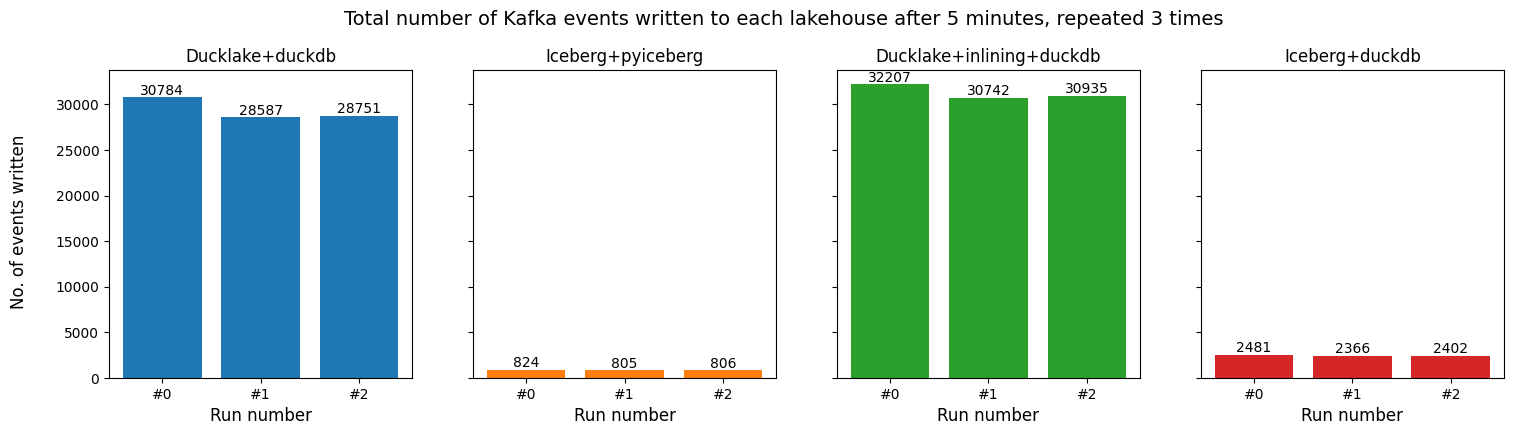

In [7]:
fig, ax = plt.subplots(1,4, figsize=(18,4), sharey=True)
fig.text(x=0.07,y=0.5,s="No. of events written", va="center", rotation="vertical",fontsize=FONT_SIZE)
# fig.tight_layout(pad=1)
fig.suptitle("Total number of Kafka events written to each lakehouse after 5 minutes, repeated 3 times", x=0.5, y=1.03, fontsize=FONT_SIZE_TITLE)
for i, ax in enumerate(ax):
    if len(title_parts := events_consumed["lakehouse"][i*3].split("-")) > 2:
        title = "+".join(title_parts[:-1])
    else:
        title = title_parts[0] 
    ax.set_title(f"{title.capitalize()}+{events_consumed["client"][i*3]}", fontsize=FONT_SIZE)
    ax.set_xlabel("Run number", fontsize=FONT_SIZE)
    ax.bar(x=list(map(lambda x: f"#{x}", range(3))), height=events_consumed["events_consumed"][i*3:(i*3)+3], facecolor=f"C{i}")
    for container in ax.containers:
        ax.bar_label(container)
    # sns.barplot(events_consumed, x="lakehouse", y="events_consumed", ax=ax[i])
    # ax[i].set_ylabel("No. of events written")
plt.show()

In [8]:
def get_hardware_metrics(run_id: int):
    return conn.query("SELECT id % 300 AS time_step, " \
                        "experiment_id, " \
                        "cpu_percentage, " \
                        "COALESCE(bytes_written - LAG(bytes_written) OVER (ORDER BY id), 0) AS bytes_written_clean," \
                        "COALESCE(write_time_ms - LAG(write_time_ms) OVER (ORDER BY id), 0) AS write_time_clean " \
                        "FROM hardware_metrics " \
                        "WHERE experiment_id = ? " \
                        "ORDER BY experiment_id;", params=[run_id]).fetchnumpy()

hardware_metrics = get_hardware_metrics(1)

In [9]:
def plot_disk_io_stats(hardware_metrics: list[np.array]):
    fig, (ax_bytes, ax_time) = plt.subplots(1,2,figsize=(16,9))
    fig.suptitle("ECDF of bytes written to disk and time spent writing at every second of the experiment for DuckLake without inlining", fontsize=FONT_SIZE_TITLE)
    
    ax_bytes.grid()
    ax_bytes.set_title("ECDF of bytes written to disk", fontsize=FONT_SIZE)
    ax_bytes.set_xlabel("Bytes written to disk", fontsize=FONT_SIZE)
    ax_bytes.set_ylabel("Percent", fontsize=FONT_SIZE)
    
    ax_time.grid()
    ax_time.set_title("ECDF of time spent writing to disk in milliseconds", fontsize=FONT_SIZE)
    ax_time.set_xlabel("Time spent writing (ms)", fontsize=FONT_SIZE)
    ax_time.set_ylabel("Percent", fontsize=FONT_SIZE)
    for i, run in enumerate(hardware_metrics):
        sns.ecdfplot(run, x="bytes_written_clean", log_scale=2, stat="percent", ax=ax_bytes, color=f"C{i}")
        sns.ecdfplot(run, x="write_time_clean", log_scale=10, stat="percent", ax=ax_time, color=f"C{i}")
    plt.show()
# plot_disk_io_stats(hardware_metrics)

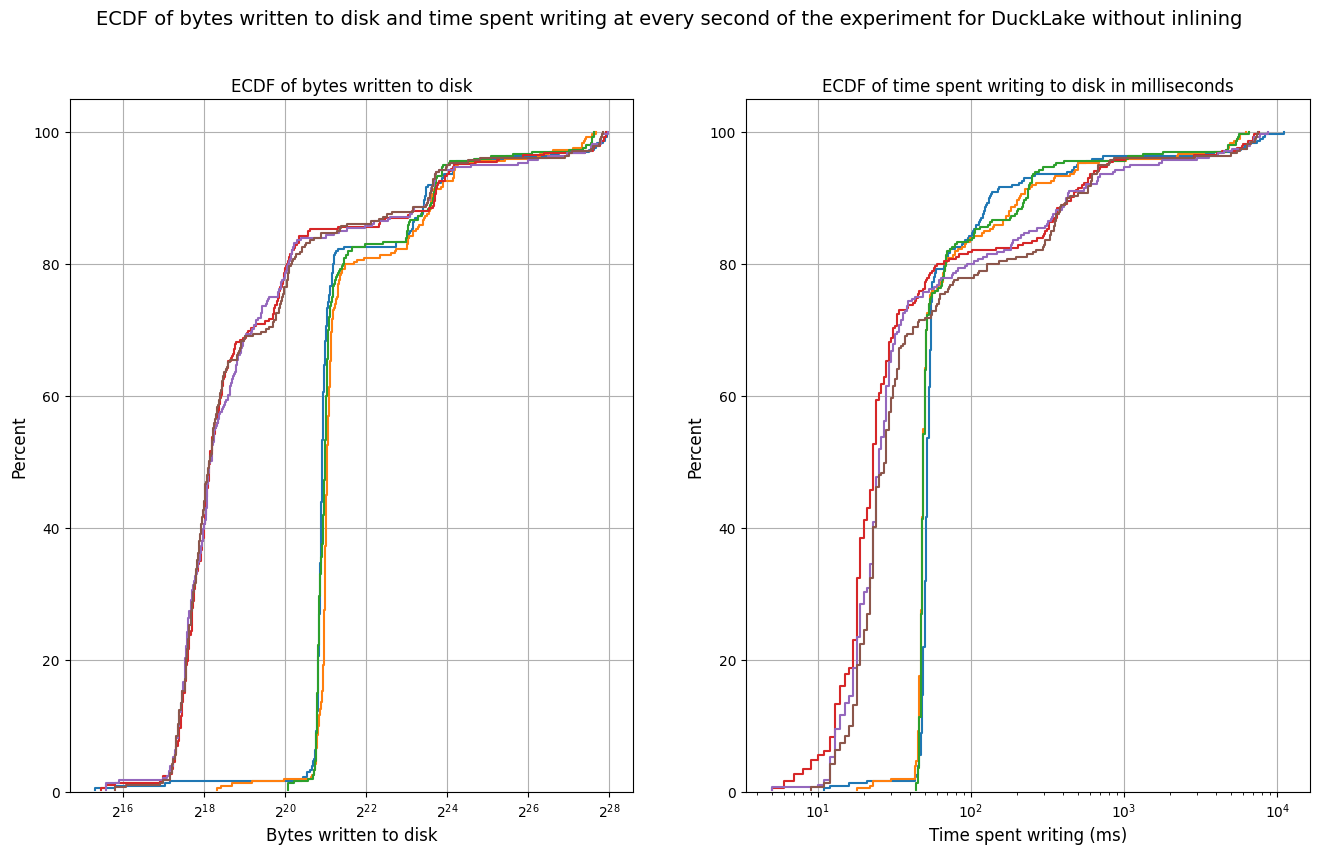

In [10]:
# plt.figure(figsize=(12,9))
# plt.grid(visible=True)
plot_disk_io_stats([get_hardware_metrics(i) for i in range(1,7)])
# plot_disk_io_stats([get_hardware_metrics(i) for i in range(4,7)])
# plt.show()

In [11]:
conn.query("SELECT * FROM experiments WHERE id IN (4,5,6);")

┌───────┬───────────┬───────────┬─────────────────┬──────────────┬──────────────┬────────────────────────┐
│  id   │ lakehouse │  client   │ events_produced │ duration_ns  │ waiting_time │ flush_inlined_duration │
│ int32 │  varchar  │  varchar  │      int32      │    int64     │    int64     │         int64          │
├───────┼───────────┼───────────┼─────────────────┼──────────────┼──────────────┼────────────────────────┤
│     4 │ iceberg-0 │ pyiceberg │          894017 │ 300515065765 │            5 │                   NULL │
│     5 │ iceberg-1 │ pyiceberg │          860887 │ 300404079276 │            5 │                   NULL │
│     6 │ iceberg-2 │ pyiceberg │          859628 │ 300075957890 │            5 │                   NULL │
└───────┴───────────┴───────────┴─────────────────┴──────────────┴──────────────┴────────────────────────┘

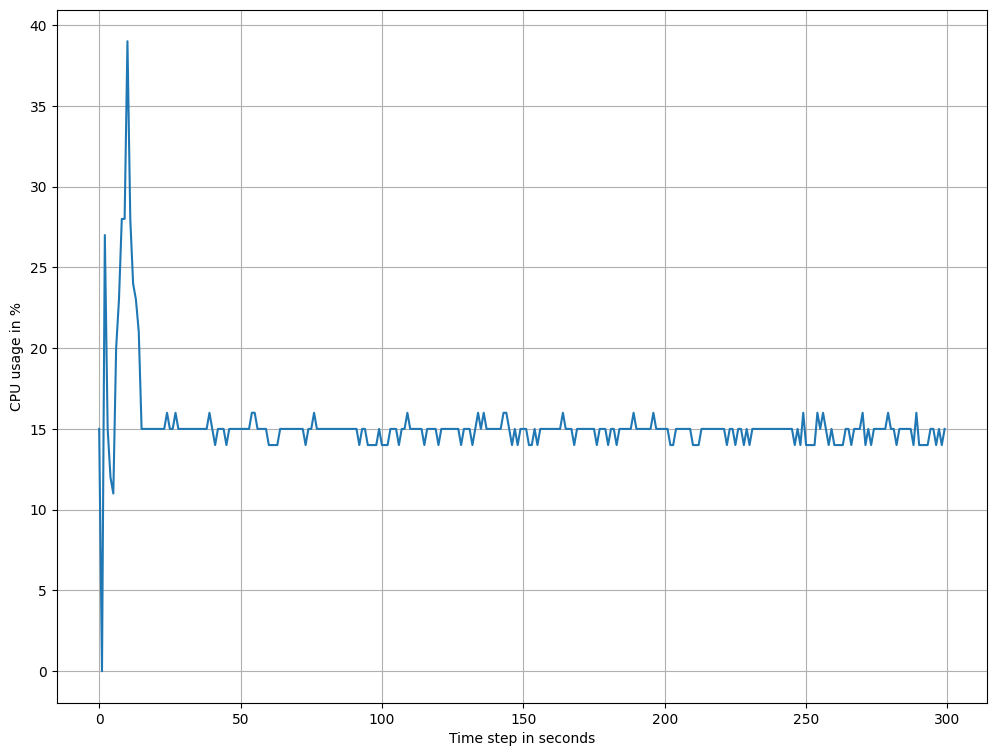

In [12]:
plt.figure(figsize=(12,9))
ax = plt.subplot()
ax.grid(visible=True)
ax.set_xlabel("Time step in seconds")
ax.set_ylabel("CPU usage in %")
sns.lineplot(get_hardware_metrics(1), x="time_step", y="cpu_percentage")
plt.show()

## Plot bytes written

In [13]:
def plot_bytes_written(disk_data: list[np.array], labels: list[str], markers: list[tuple]):
    plt.figure(figsize=(20,9))
    ax = plt.subplot()
    ax.grid(visible=True)
    ax.set_title("Number of bytes written to disk at every second, while inserting individual events to each SUT", fontsize=FONT_SIZE_TITLE)
    ax.set_xlabel("Bytes written", fontsize=FONT_SIZE)
    palette = sns.color_palette("husl", len(disk_data))
    for i, (experiment, label, (marker, marker_size)) in enumerate(zip(disk_data, labels, markers)):
        sns.stripplot(experiment, x="bytes_written_clean", log_scale=True, ax=ax, jitter=0.35, label=label, marker=marker, size=marker_size, color=palette[i])
    plt.legend(loc="best", title="SUT")
    plt.show()

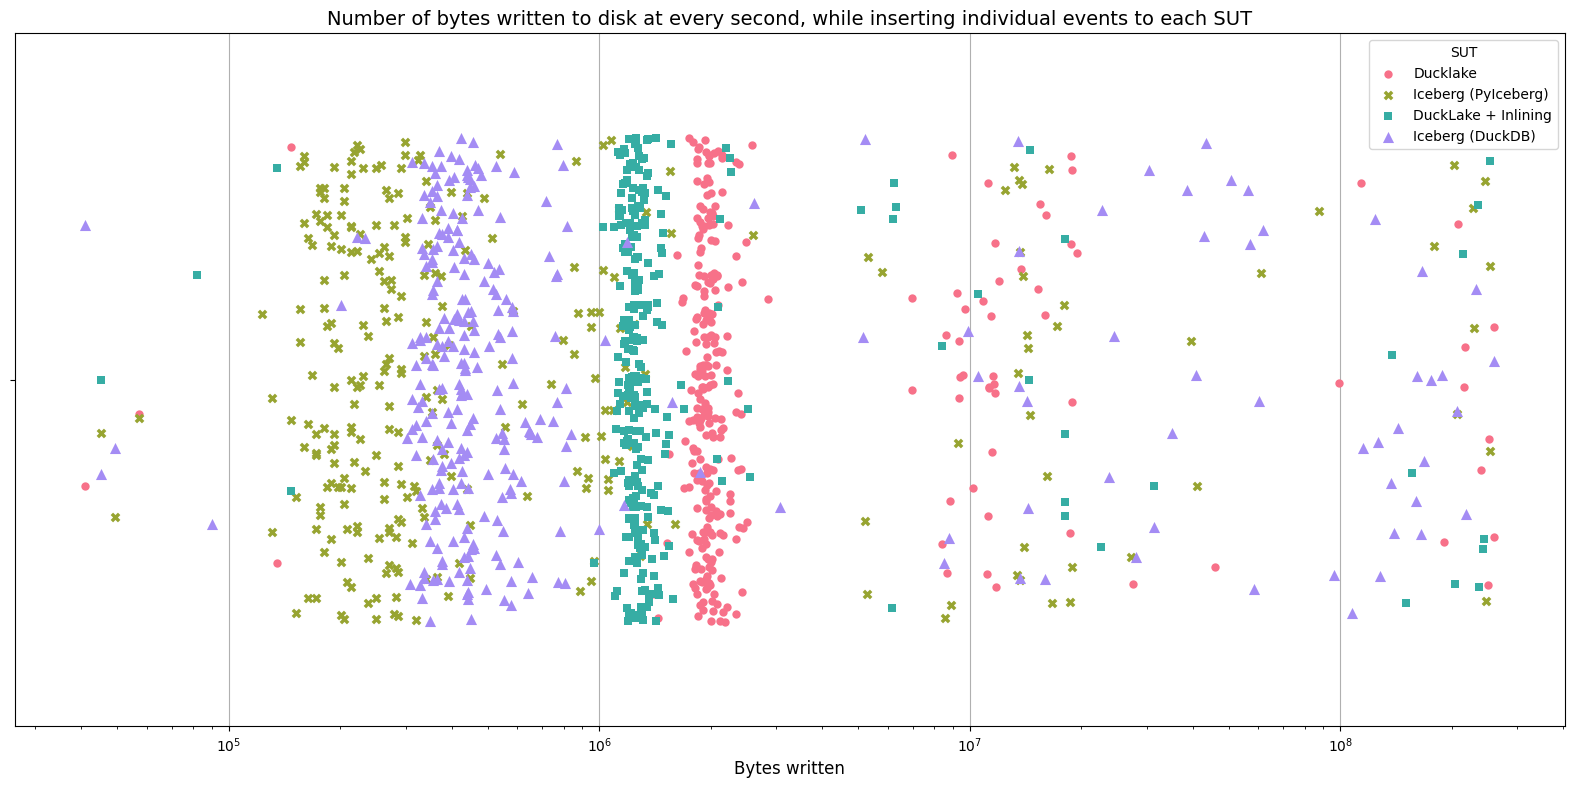

In [14]:
bytes_written_data = [get_hardware_metrics(i) for i in range(1,11,3)]
labels = ["Ducklake", "Iceberg (PyIceberg)", "DuckLake + Inlining", "Iceberg (DuckDB)"]
markers = [("o", 6), ("X", 7), ("s", 6), ("^", 8)]
plot_bytes_written(bytes_written_data, labels, markers)

## Plot read times

In [15]:
def get_read_and_write_times(experiment_ids: list[int]):
    return conn.query("SELECT CAST(experiment_id AS VARCHAR) AS experiment_id, trip_id, " \
                        "read_duration_ns AS read_time, " \
                        "write_duration_ns AS write_time " \
                        f"FROM events WHERE experiment_id IN ({",".join(["?" for _ in range(len(experiment_ids))])});", params=experiment_ids).fetchnumpy()

get_read_and_write_times([1])

{'experiment_id': array(['1', '1', '1', ..., '1', '1', '1'], shape=(30784,), dtype=object),
 'trip_id': array([    1,     2,     3, ..., 30782, 30783, 30784], shape=(30784,)),
 'read_time': array([1209837,  143639,  154203, ...,  158692,  216665,  157504],
       shape=(30784,)),
 'write_time': array([15574732, 12023301, 10791564, ...,  9592274,  9826051, 10334257],
       shape=(30784,))}

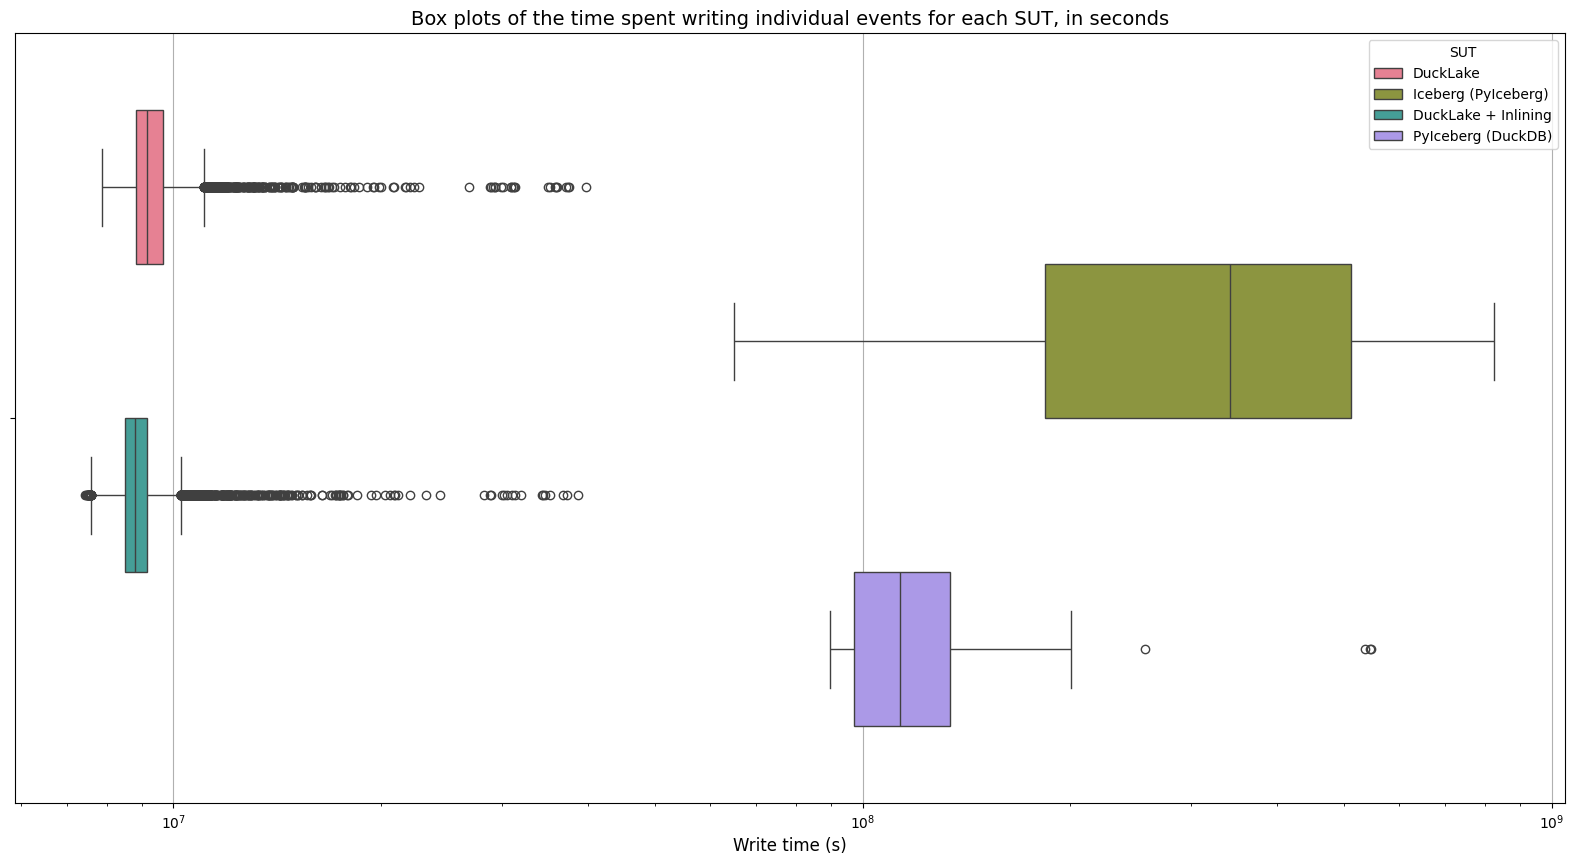

In [19]:
plt.figure(figsize=(20,10))
ax = plt.subplot()
ax.grid(visible=True)
ax.set_title("Box plots of the time spent writing individual events for each SUT, in seconds", fontsize=FONT_SIZE_TITLE)
ax.set_xlabel("Write time (s)", fontsize=FONT_SIZE)
sns.boxplot(get_read_and_write_times([i for i in range(1,11,3)]), x="write_time", hue="experiment_id", log_scale=True, palette=sns.color_palette("husl", 4))
ax.legend(title="SUT", labels=["DuckLake", "Iceberg (PyIceberg)", "DuckLake + Inlining", "PyIceberg (DuckDB)"])
plt.show()